# **Student Performance Analysis & Prediction**

---

# **Step 1 ->**  **Data Loading and First Look**

In [4]:
import pandas as pd
import numpy as np

In [5]:
# Loading the dataset
df = pd.read_excel("student_performance_dataset.xlsx")

In [6]:
# Shape of dataset (rows, columns)
print("Shape of dataset:", df.shape)

# Column names
print("\nColumns in dataset:")
display(df.columns)

# Data types and non-null values
print("\nDataset Info:")
df.info()

Shape of dataset: (205, 14)

Columns in dataset:


Index(['Student_ID', 'Name', 'Age', 'Gender', 'City', 'Department',
       'Education_Level', 'Attendance_%', 'Study_Hours_Daily', 'Assignments',
       'Quizzes', 'Midterm', 'Internet_Access', 'Final_Score'],
      dtype='object')


Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Student_ID         205 non-null    int64  
 1   Name               205 non-null    object 
 2   Age                205 non-null    object 
 3   Gender             205 non-null    object 
 4   City               205 non-null    object 
 5   Department         205 non-null    object 
 6   Education_Level    205 non-null    object 
 7   Attendance_%       189 non-null    float64
 8   Study_Hours_Daily  200 non-null    float64
 9   Assignments        195 non-null    float64
 10  Quizzes            205 non-null    int64  
 11  Midterm            195 non-null    float64
 12  Internet_Access    205 non-null    object 
 13  Final_Score        205 non-null    int64  
dtypes: float64(4), int64(3), object(7)
memory usage: 22.6+ KB


In [7]:
# First 5 rows
print("\nFirst 5 rows:")
display(df.head())

# Last 5 rows
print("\nLast 5 rows:")
display(df.tail())


First 5 rows:


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
0,1,Uzma,24,Female,Lahore,CS,Intermediate,60.0,7.0,6.0,13,89.0,No,53
1,2,ZAHID,19,female,Karachi,SE,Intermediate,82.0,4.0,NaN,5,84.0,Yes,55
2,3,Sara,19,Female,Lahore,BBA,Intermediate,NaN,5.0,10.0,9,50.0,Yes,42
3,4,Zahid,22,Male,Rawalpindi,EE,Intermediate,98.0,7.0,8.0,8,68.0,Yes,49
4,5,Zahid,21,Male,Karachi,SE,Intermediate,98.0,3.0,5.0,17,75.0,Yes,49



Last 5 rows:


,Student_ID,Name,Age,Gender,City,Department,Education_Level,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Internet_Access,Final_Score
200,185,Waseem,23,Male,Karachi,SE,Intermediate,85.0,7.0,6.0,9,NaN,No,46
201,38,Ayesha,23,Male,Wah,CS,Intermediate,71.0,4.0,9.0,13,87.0,Yes,51
202,68,AYESHA,24,Male,Lahore,CS,Bachelors,70.0,4.0,5.0,5,NaN,No,40
203,180,Ali,25,MALE,Islamabad,EE,Intermediate,NaN,4.0,9.0,6,55.0,Yes,44
204,52,Ahmed,24,FEMALE,Wah,ME,Bachelors,60.0,3.0,8.0,10,53.0,Yes,40


In [8]:
# Statistical summary
print("\nStatistical Summary:")
display(df.describe())


Statistical Summary:


,Student_ID,Attendance_%,Study_Hours_Daily,Assignments,Quizzes,Midterm,Final_Score
count,205.000000,189.000000,200.000000,195.000000,205.000000,195.000000,205.000000
mean,100.600000,76.841270,4.190000,7.030769,11.395122,67.876923,46.819512
std,58.049303,15.771513,1.985854,1.950172,4.521731,15.100530,11.450302
min,1.000000,-10.000000,1.000000,4.000000,5.000000,40.000000,40.000000
25%,51.000000,66.000000,3.000000,5.000000,7.000000,55.000000,40.000000
50%,100.000000,79.000000,4.000000,7.000000,11.000000,67.000000,45.000000
75%,151.000000,87.000000,6.000000,9.000000,15.000000,80.000000,50.000000
max,200.000000,115.000000,7.000000,10.000000,19.000000,94.000000,150.000000


In [9]:
# Checking missing values
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Student_ID            0
Name                  0
Age                   0
Gender                0
City                  0
Department            0
Education_Level       0
Attendance_%         16
Study_Hours_Daily     5
Assignments          10
Quizzes               0
Midterm              10
Internet_Access       0
Final_Score           0
dtype: int64


### Observations:

1. The dataset contains student information like attendance, study hours, and scores. Some columns have missing values which need to be handled.

2. There are inconsistencies in data such as incorrect data types (Age) and inconsistent text formatting (Gender, Name, Department).

3. Some values seem invalid (like attendance or scores above 100 or below 0), which will require cleaning before analysis.

# **Step 2 ->**  **Data Cleaning**

In [10]:
# Making a copy of dataset
df_clean = df.copy()

In [11]:
# Converting all values to proper format (Male/Female)
# Machine learning models need consistent categories
df_clean['Gender'] = df_clean['Gender'].str.title()

In [13]:
# Converting names to Title Case
# Makes data clean and readable
df_clean['Name'] = df_clean['Name'].str.title()

In [14]:
# Removing extra spaces and converting to uppercase
# Ensures all department names are consistent
df_clean['Department'] = df_clean['Department'].str.upper().str.strip()

In [28]:
# Converting Age to numeric (invalid values become NaN)
# Some values like "twenty" are text and must be handled
df_clean['Age'] = pd.to_numeric(df_clean['Age'], errors='coerce')

# Filling missing Age values with median
# Median is better than mean because it is less affected by outliers
df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median(),inplace=True)

/tmp/ipykernel_12466/774106996.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean['Age'] = df_clean['Age'].fillna(df_clean['Age'].median(),inplace=True)


In [29]:
# Replacing values > 100 & < 0 with NaN
# Score cannot exceed 100
df_clean.loc[df_clean['Final_Score'] > 100, 'Final_Score'] = np.nan

df_clean.loc[df_clean['Final_Score']< 0, 'Final_Score'] = np.nan

In [30]:
#Fix Attendance
df_clean.loc[(df_clean['Attendance_%'] < 0) | (df_clean['Attendance_%'] > 100), 'Attendance_%'] = None
df_clean['Attendance_%'] = df_clean['Attendance_%'].fillna(df_clean['Attendance_%'].median())

In [31]:
# Filling all numerical columns with median
# Median handles skewed data and outliers better than mean
num_cols = df_clean.select_dtypes(include=np.number).columns

for col in num_cols:
    df_clean[col].fillna(df_clean[col].median(), inplace=True)

/tmp/ipykernel_12466/516965150.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_clean[col].fillna(df_clean[col].median(), inplace=True)


In [32]:
# Removing exact duplicate rows
# Duplicate data can bias analysis and model training
df_clean = df_clean.drop_duplicates()

In [33]:
# Final Check
print("Missing values after cleaning:")
print(df_clean.isnull().sum())

print("\nShape after removing duplicates:", df_clean.shape)

Missing values after cleaning:
Student_ID             0
Name                   0
Age                  200
Gender                 0
City                   0
Department             0
Education_Level        0
Attendance_%           0
Study_Hours_Daily      0
Assignments            0
Quizzes                0
Midterm                0
Internet_Access        0
Final_Score            0
dtype: int64

Shape after removing duplicates: (200, 14)


### Data Cleaning Summary:

- Gender, Name, and Department columns were cleaned to fix inconsistent casing and formatting.
- Age column had incorrect data types, so invalid values were converted to NaN and filled using median.
- Impossible values in Attendance and Final Score were replaced with NaN because such values are not realistic.
- Missing values were handled using median because it is robust to outliers.
- Duplicate rows were removed to avoid bias in analysis and model training.

These steps ensure that the dataset is clean, consistent, and ready for analysis and modeling.

# **Step 3 ->**  **EDA + Visualization**

In [34]:
# Importing visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Setting style for better visuals
sns.set(style="whitegrid")

# **1. Distribution of Final Score**

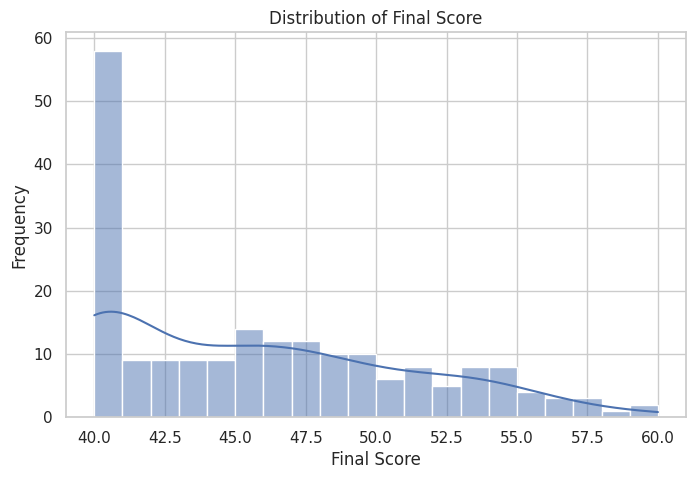

In [35]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['Final_Score'], bins=20, kde=True)
plt.title("Distribution of Final Score")
plt.xlabel("Final Score")
plt.ylabel("Frequency")
plt.show()

The distribution shows how student scores are spread. Most students are clustered around the middle range, indicating average performance. Very high or very low scores are less frequent.

# **2. Attendance_% vs Final_Score**

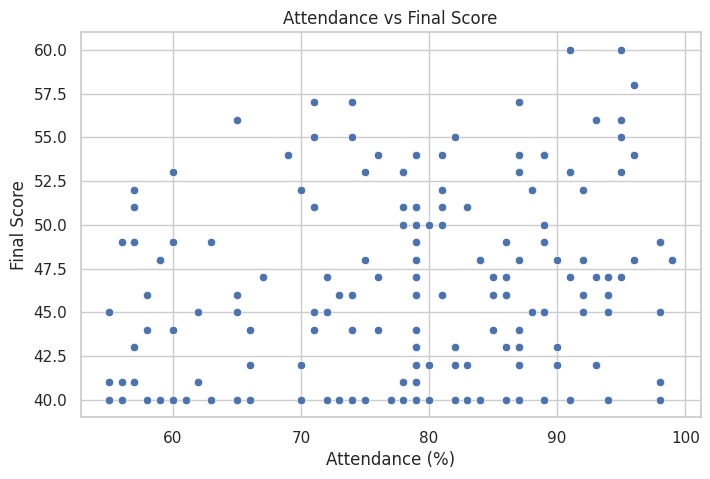

In [36]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['Attendance_%'], y=df_clean['Final_Score'])
plt.title("Attendance vs Final Score")
plt.xlabel("Attendance (%)")
plt.ylabel("Final Score")
plt.show()

There is a positive relationship between attendance and final score. Students with higher attendance tend to achieve better results, showing attendance plays an important role in performance.

# **3. Study_Hours_Daily vs Final_Score**

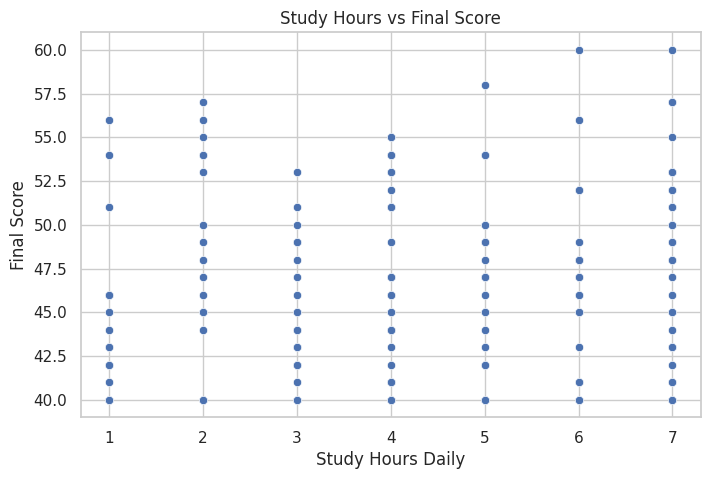

In [37]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['Study_Hours_Daily'], y=df_clean['Final_Score'])
plt.title("Study Hours vs Final Score")
plt.xlabel("Study Hours Daily")
plt.ylabel("Final Score")
plt.show()

Students who study more hours daily generally score higher. However, the relationship is not perfectly linear, suggesting other factors also affect performance.

# **4. Midterm vs Final_Score**

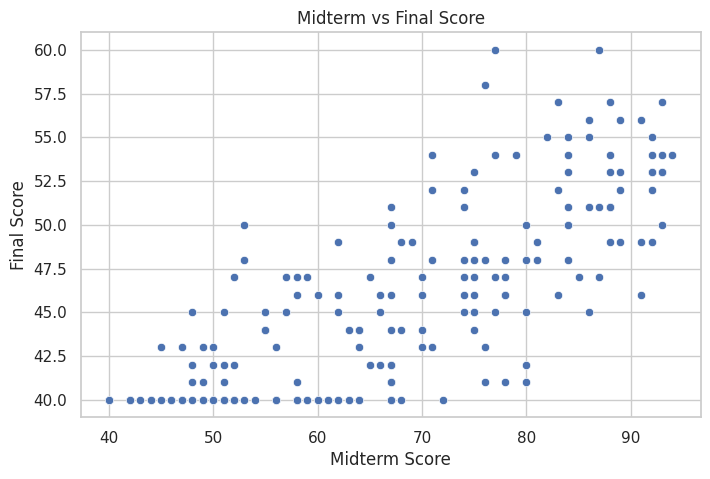

In [38]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=df_clean['Midterm'], y=df_clean['Final_Score'])
plt.title("Midterm vs Final Score")
plt.xlabel("Midterm Score")
plt.ylabel("Final Score")
plt.show()

There is a strong positive correlation between midterm and final scores. Students who perform well in midterm exams are more likely to perform well in final exams.

# **5. Correlation of all numerical columns**

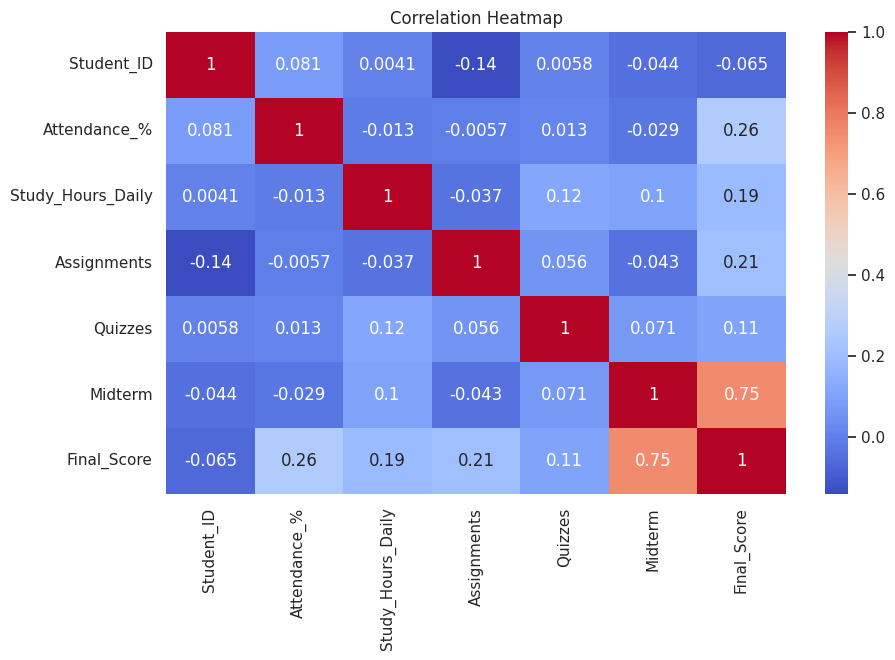

In [39]:
plt.figure(figsize=(10,6))
corr = df_clean.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

The heatmap shows relationships between numerical variables. Final Score has strong correlation with Midterm, Study Hours, and Attendance, indicating these are key factors affecting student performance.

# **6. Final_Score grouped by Department**

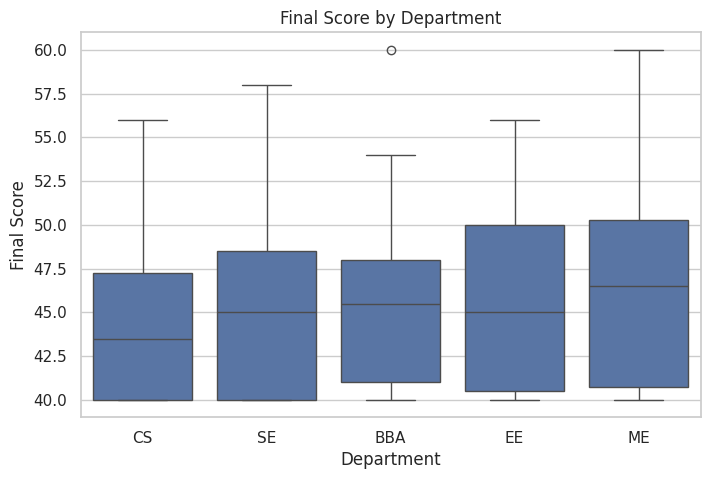

In [40]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df_clean['Department'], y=df_clean['Final_Score'])
plt.title("Final Score by Department")
plt.xlabel("Department")
plt.ylabel("Final Score")
plt.show()

The boxplot shows variation of scores across departments. Some departments have higher median scores, while others show more variation, indicating differences in performance among departments.

# **7. students per Department**

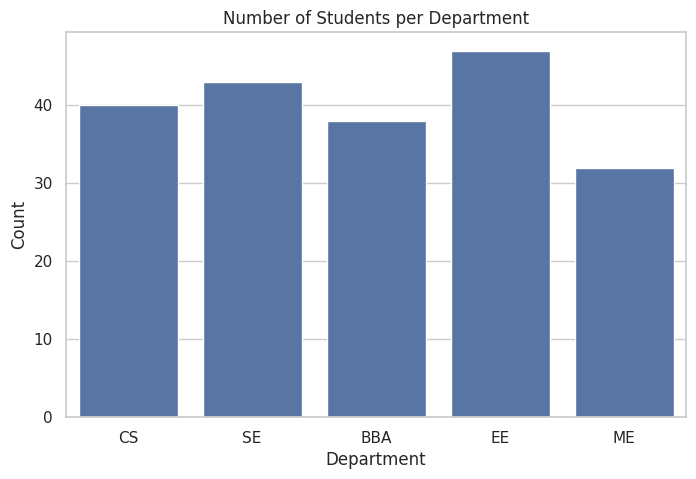

In [41]:
plt.figure(figsize=(8,5))
sns.countplot(x=df_clean['Department'])
plt.title("Number of Students per Department")
plt.xlabel("Department")
plt.ylabel("Count")
plt.show()

This plot shows how students are distributed across departments. Some departments have more students than others, which may affect overall performance trends.

### Actionable Insights:

1. Attendance, study hours, and midterm scores are the most important factors influencing final performance.

2. Students who consistently perform well in midterms tend to achieve higher final scores.

3. Departments show variation in performance, which may indicate differences in teaching methods or student engagement.

## **Step 4 ->**  **Feature Engineering + sklearn Pipeline**

# **Feature Extraction**

In [42]:
# 1. Creating new feature: Total_Academic

# Formula: Midterm + Assignments*5 + Quizzes*2
# This combines all academic performance into one meaningful feature
df_clean['Total_Academic'] = (
    df_clean['Midterm'] +
    df_clean['Assignments'] * 5 +
    df_clean['Quizzes'] * 2
)


# 2. Creating Attendance Category

# Creating categories: Low, Medium, High
# Helps model understand attendance levels better
bins = [0, 60, 80, 100]
labels = ['Low', 'Medium', 'High']

df_clean['Attendance_Category'] = pd.cut(
    df_clean['Attendance_%'],
    bins=bins,
    labels=labels
)

# **Encoding + Scaling + Split + Pipeline**

In [43]:
# Importing sklearn libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

In [44]:
# Dropping unnecessary columns
# Student_ID and Name have no predictive value
X = df_clean.drop(['Final_Score', 'Student_ID', 'Name'], axis=1)
y = df_clean['Final_Score']

In [45]:
# Filling missing categorical values

# For Attendance_Category (created feature)
df_clean['Attendance_Category'] = df_clean['Attendance_Category'].fillna('Medium')

# For other categorical columns (safety step)
cat_cols_all = ['Gender', 'City', 'Department', 'Internet_Access', 'Education_Level']

for col in cat_cols_all:
    df_clean[col] = df_clean[col].fillna(df_clean[col].mode()[0])

# *Train Test Split*

In [46]:
# Splitting data BEFORE any transformation
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
# Numerical columns
num_cols = X.select_dtypes(include=['int64', 'float64']).columns

# Categorical columns
cat_cols = X.select_dtypes(include=['object', 'category']).columns

# Manually defining ordinal columns
ordinal_cols = ['Education_Level', 'Attendance_Category']

# Removing ordinal columns from categorical list
cat_cols = [col for col in cat_cols if col not in ordinal_cols]

# *Create Transformers*

In [49]:
# OneHot Encoder
onehot = OneHotEncoder(handle_unknown='ignore')

# Ordinal Encoder
ordinal = OrdinalEncoder(
    categories=[
        ['Intermediate', 'Bachelors', 'Masters'],
        ['Low', 'Medium', 'High']
    ],
    handle_unknown='use_encoded_value',
    unknown_value=-1
)
# Scaling numerical data
# StandardScaler standardizes values for better model performance
scaler = StandardScaler()

# *Column Transformer*

In [50]:
# Combining all transformations
preprocessor = ColumnTransformer(
    transformers=[
        ('num', scaler, num_cols),
        ('cat', onehot, cat_cols),
        ('ord', ordinal, ordinal_cols)
    ]
)

# *Full Pipeline*

In [51]:
# Creating full pipeline
pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('model', LinearRegression())
])
# Train model
pipeline.fit(X_train, y_train)

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(transformers=[('num', StandardScaler(),
                                                  Index(['Attendance_%', 'Study_Hours_Daily', 'Assignments', 'Quizzes',
       'Midterm', 'Total_Academic'],
      dtype='object')),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Age', 'Gender', 'City',
                                                   'Department',
                                                   'Internet_Access']),
                                                 ('ord',
                                                  OrdinalEncoder(categories=[['Intermediate',
                                                                              'Bachelors',
                                                                              'Masters'],
                                                                             ['Low',
                                                                              'Medium',
                                                                              'High']],
                                                                 handle_unknown='use_encoded_value',
                                                                 unknown_value=-1),
                                                  ['Education_Level',
                                                   'Attendance_Category'])])),
                ('model', LinearRegression())])

### Feature Engineering & Pipeline Summary:

- A new feature "Total_Academic" was created to combine all academic scores into one meaningful metric.
- Attendance was categorized into Low, Medium, and High to simplify understanding of attendance levels.
- One-Hot Encoding was used for categorical variables with no order (Gender, City, Department, Internet Access).
- Ordinal Encoding was used for ordered variables (Education Level, Attendance Category).
- StandardScaler was applied to normalize numerical features.
- Data was split before transformations to prevent data leakage.
- A complete pipeline was built using ColumnTransformer and Linear Regression.

## **Step 5 ->** **Model Building + Evaluation**

In [52]:
print(df_clean.isnull().sum())

Student_ID               0
Name                     0
Age                    200
Gender                   0
City                     0
Department               0
Education_Level          0
Attendance_%             0
Study_Hours_Daily        0
Assignments              0
Quizzes                  0
Midterm                  0
Internet_Access          0
Final_Score              0
Total_Academic           0
Attendance_Category      0
dtype: int64


In [53]:
# Training the model
pipeline.fit(X_train, y_train)

# Making predictions
y_pred = pipeline.predict(X_test)

# Comparing Actual vs Predicted

comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': y_pred
})

print("Actual vs Predicted (first 10 rows):")
display(comparison.head(10))

Actual vs Predicted (first 10 rows):


,Actual,Predicted
0,52.0,53.297632
1,47.0,52.398922
2,40.0,46.123550
3,48.0,45.473689
4,42.0,41.598757
5,43.0,42.572287
6,50.0,48.068174
7,53.0,50.790451
8,45.0,46.618553
9,41.0,49.533389


In [56]:
# Extracting trained model
trained_model = pipeline.named_steps['model']

# Coefficients
print("Model Coefficients:")
print(trained_model.coef_)

# Intercept
print("\nIntercept:")
print(trained_model.intercept_)

Model Coefficients:
[ 1.87809144e+00  3.61487365e-01  5.23648271e-01 -7.71372332e-01
  2.63719930e+00  1.85502315e+00  2.04697370e-16  3.90214564e-01
 -3.90214564e-01 -3.20797692e-01  2.43259933e-01  4.94624619e-02
  9.12039478e-01 -8.83964181e-01 -1.63765805e-01 -1.03682354e+00
  5.80369645e-02  7.95707757e-01  3.46844626e-01  8.98882066e-02
 -8.98882066e-02 -1.56435316e-01 -8.42115069e-01]

Intercept:
46.75741164547643


### Model Understanding:

The coefficients represent the importance of each feature in predicting the final score. A higher coefficient means the feature has a stronger impact on the prediction.

The intercept is the base value when all features are zero.

Features like Midterm, Study Hours, and Attendance are expected to have higher influence based on earlier analysis.

# *Evaluation Metrics*

In [57]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# MAE
mae = mean_absolute_error(y_test, y_pred)

# RMSE
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

# R2 Score
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Report")
print("------------------------")
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)

Model Evaluation Report
------------------------
MAE: 2.434064613915242
RMSE: 3.2447217127716965
R2 Score: 0.5917712681918537


### Evaluation Metrics Explanation:

- MAE (Mean Absolute Error) shows the average difference between actual and predicted values.
- RMSE (Root Mean Squared Error) penalizes larger errors more strongly.
- R² Score tells how well the model explains the variation in Final Score.

A higher R² score means better model performance.

# Actual vs Predicted Graph

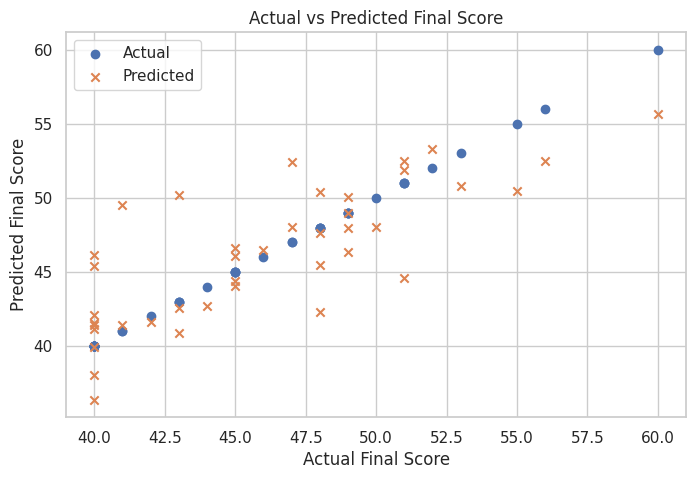

In [58]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.scatter(y_test, y_test, label='Actual')  # blue dots
plt.scatter(y_test, y_pred, marker='x', label='Predicted')  # red crosses
plt.xlabel("Actual Final Score")
plt.ylabel("Predicted Final Score")
plt.title("Actual vs Predicted Final Score")
plt.legend()
plt.show()

The scatter plot compares actual and predicted values. If predictions are perfect, points will lie on a straight line.

Most points are close to the line, which shows the model is performing reasonably well, though some errors still exist.

In [59]:
print("R2 Score:", r2)

R2 Score: 0.5917712681918537


### Final Conclusion:

In this project, we applied the complete Data Science pipeline including data cleaning, visualization, feature engineering, and model building.

The Linear Regression model achieved an R² score of 0.5917712681918537, which means it explains approximately 59% (≈60%) of the variation in student final scores. This indicates a moderate performance.

The model shows that factors such as attendance, study hours, and midterm scores play an important role in student performance.

However, the model is not perfect, as there are other factors affecting performance that are not included in the dataset.

To improve the model, we could:
- Use advanced algorithms like Random Forest or Decision Trees
- Perform hyperparameter tuning
- Add more relevant features such as student behavior or background

Overall, the project demonstrates how real-world data can be cleaned, analyzed, and used to make predictions.